Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* No ResNet
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  133


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  29


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

### Adding 80 blocks (MaxPool2D in each second block)

In [7]:
out_channels = 8
size = 64

model_blocks = [
    nn.Conv2d(3, out_channels, 3, 1, 1),
    nn.BatchNorm2d(out_channels),
    nn.ReLU()
]

for stage in range(5):

    for i in range(20):

        conv = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        bn = nn.BatchNorm2d(out_channels)

        model_blocks.extend([conv, bn, nn.ReLU()])

    if stage < 3:
        model_blocks.append(nn.MaxPool2d(2, 2))
        size //= 2
    if stage<4:
        model_blocks.extend([
            nn.Conv2d(out_channels, out_channels*2, 3, 1, 1),
            nn.BatchNorm2d(out_channels*2),
            nn.ReLU()
    ])

        out_channels *= 2

print(f"Final Out Channels = {out_channels}")
print(f"Final Shape = {size}")

Final Out Channels = 128
Final Shape = 8


In [8]:
model = model.add(
    # Conv Blocks
    *model_blocks,
    
    # Flatten
    nn.Flatten(),

    nn.Linear(out_channels * size * size, out_channels),
    nn.ReLU(),
    nn.Linear(out_channels, 3)
    )

### Use Trainer to train and check validations
Adding weight decay and decreased weight

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

In [10]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment6/",
    save_checkpoints=10,
    print_every=5
    )

In [11]:
history = trainer.fit(100)

Epoch [5/100] | Train Loss: 1.0949 | Val Loss: 1.1385 | Train Acc: 0.3596 | Val Acc: 0.3496 | Train F1: 0.2911 | Val F1: 0.2142
Epoch [10/100] | Train Loss: 1.0891 | Val Loss: 1.1217 | Train Acc: 0.3686 | Val Acc: 0.3584 | Train F1: 0.2547 | Val F1: 0.2135
Epoch [15/100] | Train Loss: 1.0906 | Val Loss: 1.1370 | Train Acc: 0.3677 | Val Acc: 0.3717 | Train F1: 0.2830 | Val F1: 0.2449
Epoch [20/100] | Train Loss: 1.0836 | Val Loss: 1.1538 | Train Acc: 0.3852 | Val Acc: 0.3650 | Train F1: 0.3046 | Val F1: 0.2289
Epoch [25/100] | Train Loss: 1.0839 | Val Loss: 1.1129 | Train Acc: 0.3677 | Val Acc: 0.3739 | Train F1: 0.2601 | Val F1: 0.2373
Epoch [30/100] | Train Loss: 1.0825 | Val Loss: 1.1533 | Train Acc: 0.3733 | Val Acc: 0.3872 | Train F1: 0.2619 | Val F1: 0.2584
Epoch [35/100] | Train Loss: 1.0755 | Val Loss: 1.1729 | Train Acc: 0.3828 | Val Acc: 0.3628 | Train F1: 0.2841 | Val F1: 0.2251
Epoch [40/100] | Train Loss: 1.0720 | Val Loss: 1.1247 | Train Acc: 0.3748 | Val Acc: 0.3606 | Tra

### Save Metrics

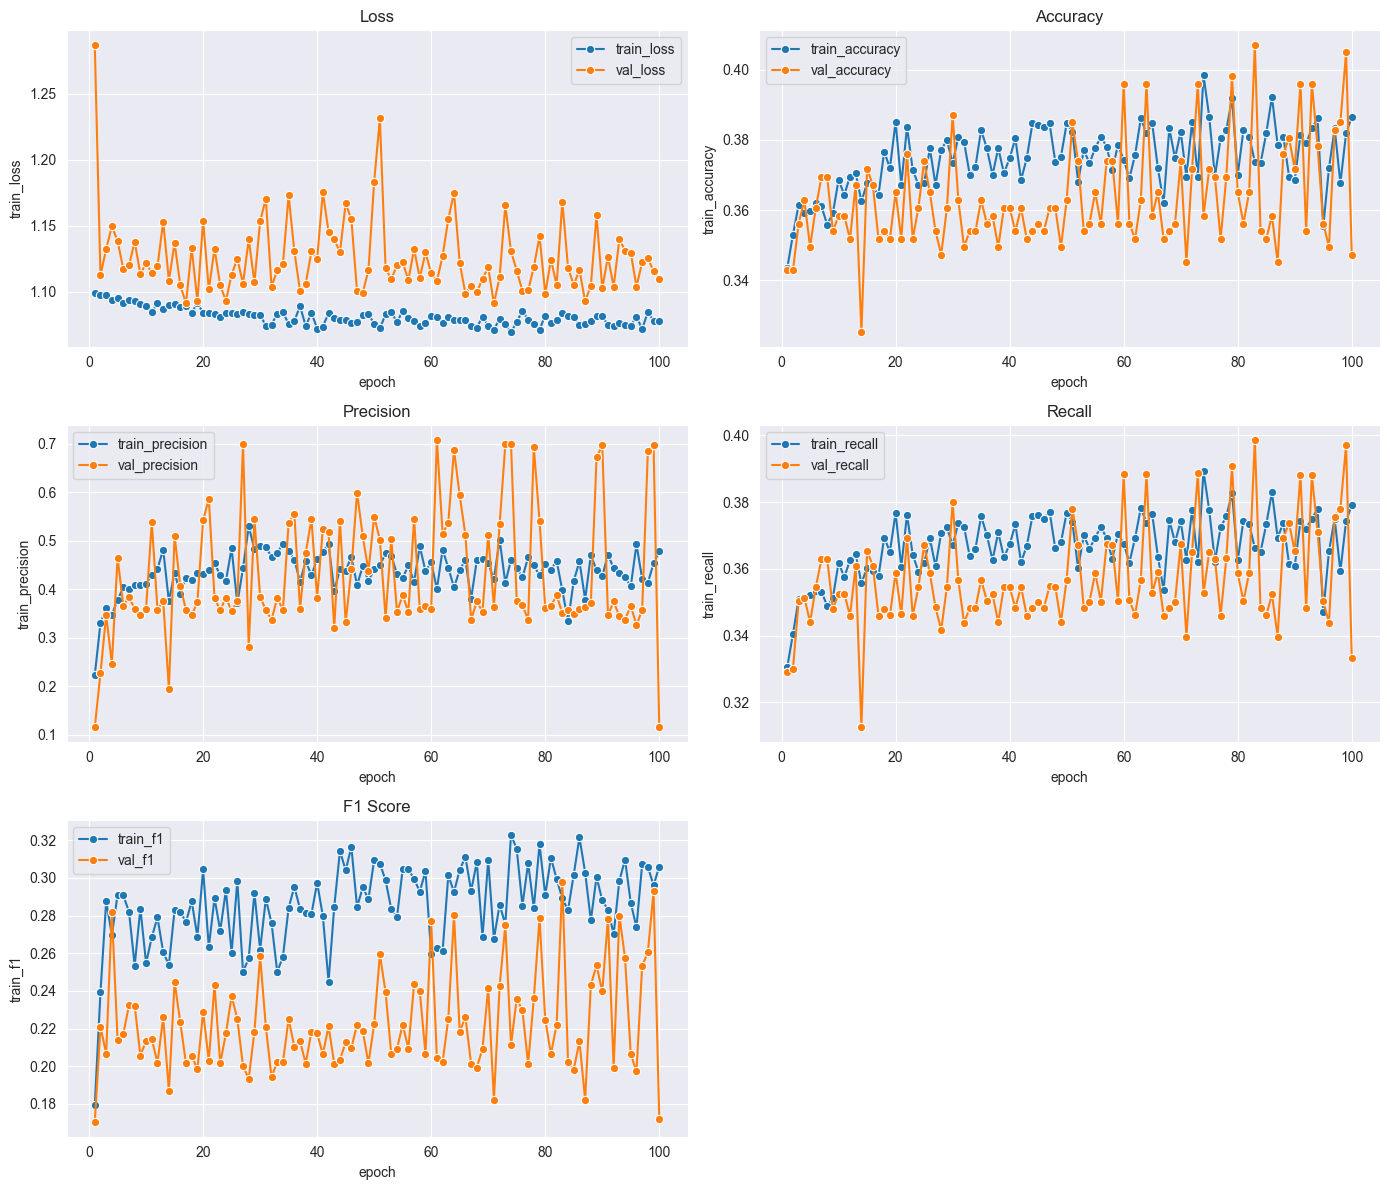

In [12]:
df = plot_training_metrics(history)
df.to_csv("../documentations/experiments/experiment6/tables/training_metrics.csv", index=False)

### Training/Validation Trend (100 epochs)
* The model starts with very low performance, with training and validation accuracy around 34%, indicating near-random initial classification.
* Training loss gradually decreases from 1.0986 to around 1.07, showing slow optimization progress.
* Validation loss does not consistently decrease and fluctuates between approximately 1.09 and 1.23, indicating unstable generalization.
* Training accuracy improves slowly from 34.36% to a maximum around 39–40%, showing limited learning capacity.
* Validation accuracy remains mostly between 34% and 40%, with only occasional improvements.
* Training precision increases over epochs, reaching values above 0.5 in some epochs, but this improvement is inconsistent.
* Training recall remains relatively stable around 35–38%, showing that the model is not significantly improving its ability to identify all classes.
* Training F1-score improves from approximately 0.18 to around 0.32, but remains low overall.
* Validation precision fluctuates heavily, sometimes becoming high due to prediction bias toward specific classes rather than balanced improvement.
* Validation recall remains around 35–40%, indicating limited class recognition ability.
* Validation F1-score remains low throughout training, generally staying between 0.18 and 0.29.
* The confusion matrices show strong class prediction imbalance, with the model frequently predicting one dominant class and struggling with other classes.
* Around later epochs, the model improves slightly but does not show a clear convergence pattern.
* The best validation performance occurs around epoch 83, where the model achieves its highest validation F1-score and accuracy.
* The model does not show strong overfitting because training performance itself remains low; instead, it appears to suffer from underfitting or insufficient feature learning.

Overall, the model learns gradually but achieves only limited improvement across 100 epochs. Training loss decreases slightly, but validation performance remains unstable, suggesting that the learned representations are not sufficiently discriminative. The model shows a tendency toward biased class predictions, as visible from the confusion matrices where some classes are frequently misclassified. Although later epochs provide small improvements, the overall accuracy and F1-score remain low, indicating that the current architecture, training strategy, or data representation may need further improvement.

<b>Best Epoch 83</b>

<b>Loss</b>
* Train Loss = 1.0836250540
* Valid Loss = 1.1683253749

<b>Training Metrics</b>
* Train Accuracy = 0.3738185167
* Train Precison = 0.3970238268
* Train Recall = 0.3662246764
* Train F1 = 0.2891205251

<b>Validation Accuracy</b>
* Validation Accuracy = 0.4070796371
* Validation Precision = 0.3504330218
* Validation Recall = 0.3987066746
* Validation F1 = 0.2978943586

## Use Tester Module to Test Model

Load Model with State Dict

In [13]:
# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

tester = Tester(
    model,
    test_loader,
    3,
    torch.nn.CrossEntropyLoss(),
    "cuda"
)

test_scores = tester.test_all_checkpoints(
    "../models/experiment6"
)

Finished testing epoch 1
Finished testing epoch 2
Finished testing epoch 3
Finished testing epoch 4
Finished testing epoch 7
Finished testing epoch 10
Finished testing epoch 15
Finished testing epoch 20
Finished testing epoch 22
Finished testing epoch 30
Finished testing epoch 40
Finished testing epoch 50
Finished testing epoch 60
Finished testing epoch 70
Finished testing epoch 79
Finished testing epoch 80
Finished testing epoch 83
Finished testing epoch 90
Finished testing epoch 100


### Save Test Metrics

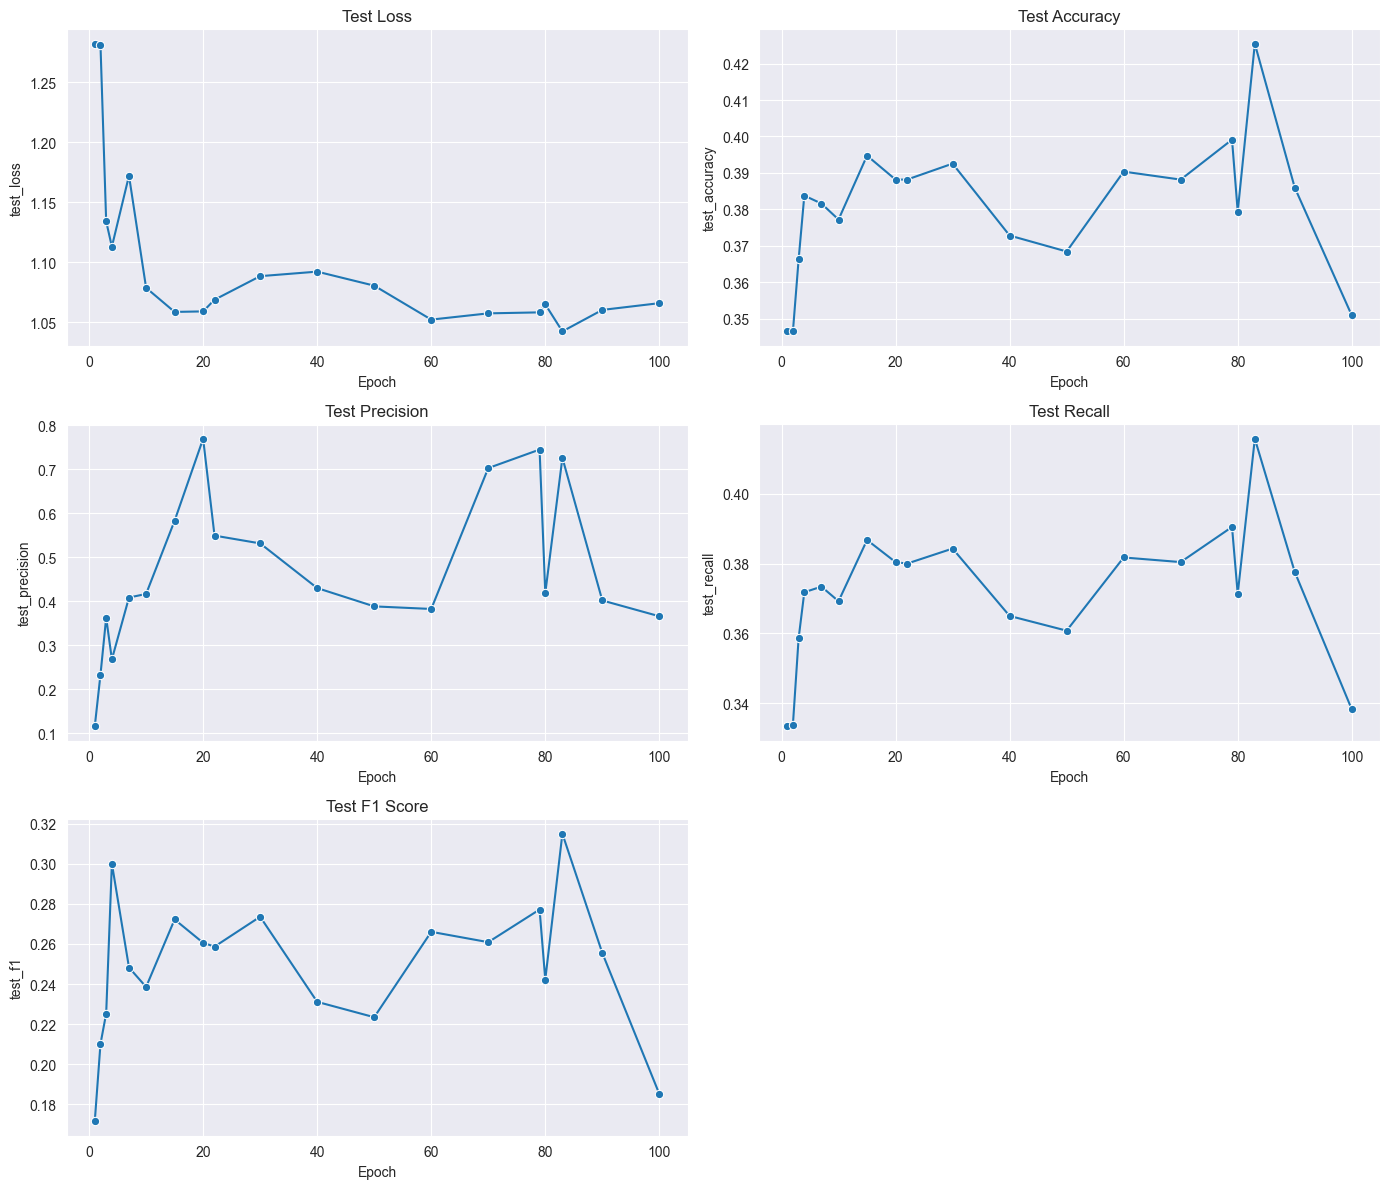

In [14]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/experiments/experiment6/tables/test_metrics.csv", index=False)

### Test Performance Trend
* The model begins with weak testing performance, with accuracy around 34.6%, indicating poor initial generalization.
* Test loss decreases from 1.28 in early epochs to around 1.04–1.06 in later epochs, showing some optimization improvement.
* Test accuracy gradually improves from 34.6% to a peak of 42.5% at epoch 83.
* Precision fluctuates significantly across epochs, with occasional high values caused by uneven class predictions rather than consistent improvement.
* Recall remains relatively stable around 33–41%, indicating limited improvement in detecting all classes.
* F1-score improves slowly from 0.17 initially to a maximum of approximately 0.315 at epoch 83.
* The best testing performance occurs around epoch 83, where accuracy, precision, recall, and F1-score are simultaneously highest.
* After epoch 83, testing performance declines, especially by epoch 100 where accuracy drops to 35.1% and F1-score falls to 0.185.
* The model shows unstable generalization, with several epochs producing higher precision but lower recall, suggesting prediction bias toward certain classes.
* The testing behaviour closely matches the validation behaviour, indicating that the validation results are representative of real model performance.
* The model does not achieve strong classification performance, suggesting that the learned features are insufficient for separating the classes effectively.

Overall, the testing results indicate that the model learns some useful features during training but reaches only moderate generalization ability. Performance improves gradually until approximately epoch 83, where it achieves the strongest balance between accuracy and F1-score. After this point, the model begins to lose generalization capability, suggesting that further training does not improve performance. The maximum test accuracy of 42.54% and F1-score of 31.50% indicate that the model is only partially learning the class patterns and still struggles with balanced classification.

<b>Best Epoch 28</b>

* Loss = 1.0423376149
* Accuracy = 0.4254385829
* Precision = 0.7259259224
* Recall = 0.4157514572
* F1-Score = 0.3149776161